In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, itertools, pickle
from IPython.display import clear_output
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from numba import njit 

from python import forces, integrators, random_matrix, simulate, densities, plotters, solvers, newton
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix); importlib.reload(newton);
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters); importlib.reload(solvers);

---

Produce fine grid of $dts$ between 1/N and $1/N^3$. Use $50$ different inits from the GUE, run one step, see how many total crossings across $1000$ trials for every init for each dt.

In [ ]:
@njit 
def init_gue_eigenvalues(M, N):
    """ 
    Generates M independent trials of GUE eigenvalues.
    Returns ndarray, shape (M, N). For large N follows Wigner's semicircle law.
    """

    eigenvalues = np.zeros((M, N))
    for m in range(M):
        A = np.random.normal(0, 1, (N, N)) + 1j*np.random.normal(0, 1, (N, N))
        mat = (A + A.conj().T) / (2.0*np.sqrt(N))
        eigenvalues[m, :] = np.linalg.eigvalsh(mat)

    return eigenvalues

@njit 
def count_crossings(x):
    M, N = x.shape 
    num_crossings = 0 

    for m in range(M):
        for i in range(N - 1):
            if (x[m, i] >= x[m, i+1]):
                num_crossings += 1
                break

    return num_crossings

@njit 
def take_step(init, dt):
    # Take Euler step.
    M, N = init.shape 
    coulomb = forces.coulomb_interaction(init)
    v_prime = forces.grad_quadratic(init)
    noise_scale = np.sqrt(dt/N) # 2*dt/beta*N but beta=2.

    step = integrators.euler_step(init, coulomb, v_prime, dt, noise_scale)
    num_crossings = count_crossings(step)

    return num_crossings # Of the M trials.

@njit 
def crossing_experiment(M, N_range, num_dts):
    dt_crossings = []
    dt_values = []

    for N in N_range:
        init = init_gue_eigenvalues(M, N)
        dt_range = np.linspace(1/N**3, 1/N**4, num_dts) # smaller than theoretical bound
        crossings_per_dt = np.zeros_like(dt_range, dtype = np.float64)

        for k, dt in enumerate(dt_range):
            total_crossings = take_step(init, dt)/M
            crossings_per_dt[k] = total_crossings

        dt_crossings.append(crossings_per_dt)
        dt_values.append(dt_range)

    return dt_crossings, dt_values

M = int(10**6)
num_dts = 50
N_range = np.logspace(np.log10(15.1), np.log10(70.1), 5, dtype = int)
print(N_range) # 

dt_crossings, dt_values = crossing_experiment(M, N_range, num_dts)

[15 22 32 47 70]


In [ ]:
def first_index_all_zero_after(arr):
    arr = np.asarray(arr)
    nonzero_idx = np.nonzero(arr)[0]
    
    if len(nonzero_idx) == 0:
        return 0  # everything is zero
    
    return nonzero_idx[-1] + 1  # index right after the last nonzero element

# =================
no_cross_dts = np.zeros_like(N_range, dtype = np.float64)

for j in range(len(dt_crossings)):
    last_dt_index = first_index_all_zero_after(dt_crossings[j])
    print(f"Index for N {N_range[j]} is", last_dt_index)

    if (last_dt_index != 100):
        no_cross_dts[j] = dt_values[j][last_dt_index]
    else:
        print("Failing this.")

-2.581479116481068


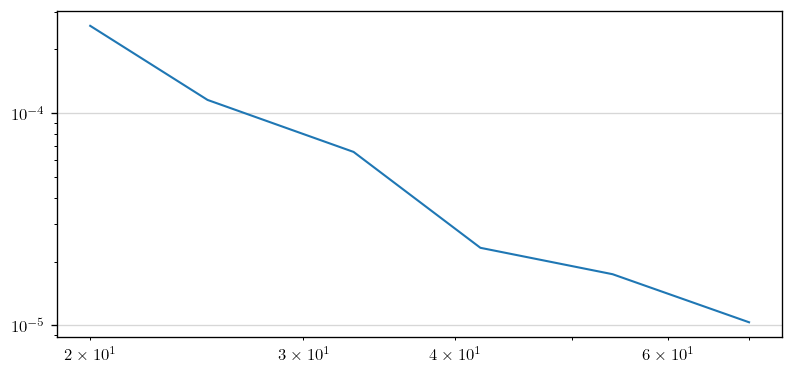

In [ ]:
fig, ax = plt.subplots()
ax.loglog(N_range, no_cross_dts, marker = 'x')
plt.show()

slope, intercept = np.polyfit(np.log10(N_range), np.log10(no_cross_dts), 1)
slope

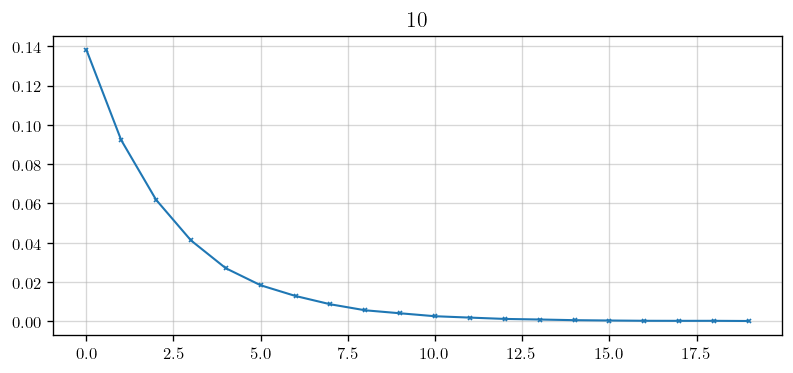

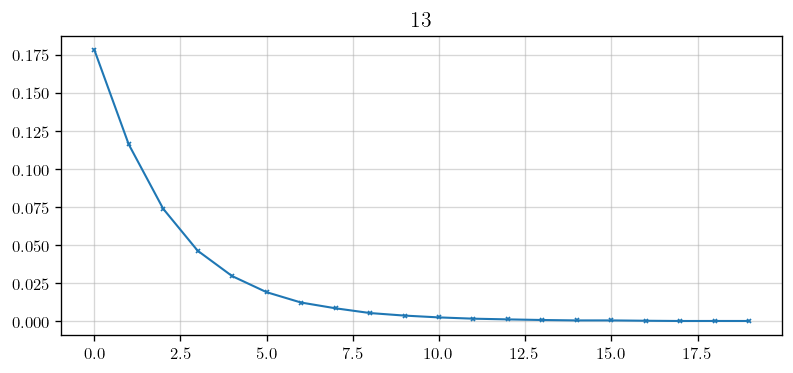

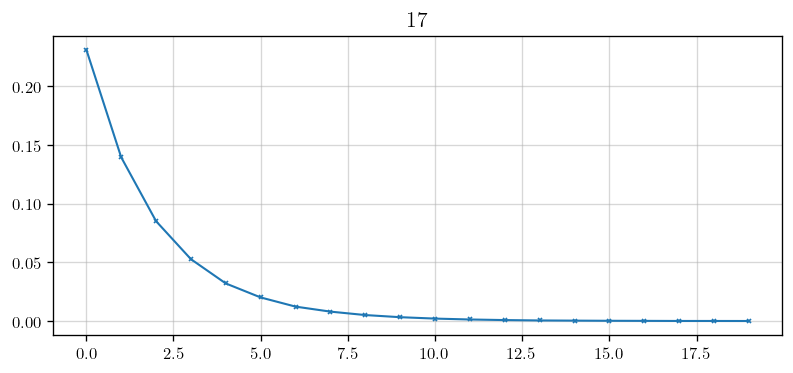

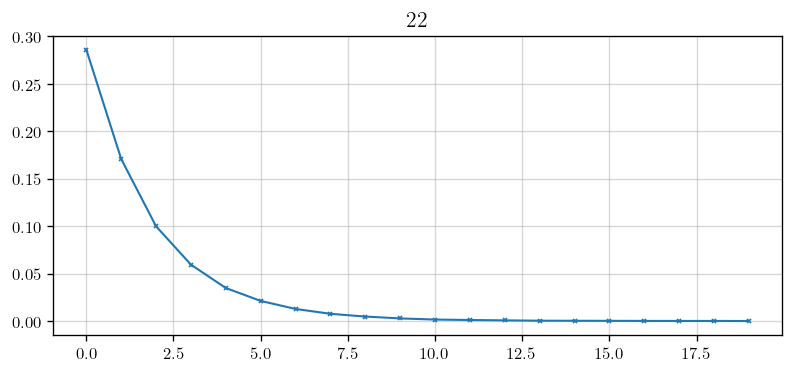

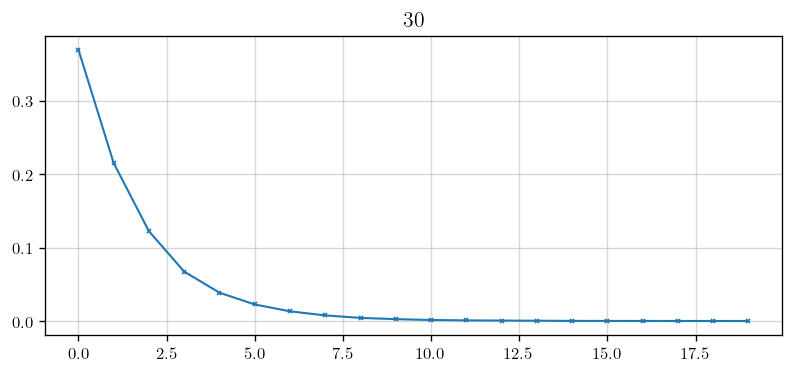

In [16]:
for j, N in enumerate(N_range):
    plt.plot(dt_crossings[j], marker = 'x')
    plt.title(N)
    plt.show()

plt.show()

---

Better: set a maximal number of crossings and find $k$ in $N^{k}$ s.t. that number is hit (within some tolerance).
 

In [3]:
beta = 2.0; pot_int = 2;

def run_single_step(init, N, dt, method, newton_tol):
    # Run one step, return num crossings (probability).
    noise_scale = np.sqrt(2.0*dt/(beta*N))
    
    if (method.lower() == "imla"):
        # If want, track Newton iterations here.
        x_next, _, newton_iters, mean_cg_iters = integrators.imla_newton_step(init, dt, pot_int, noise_scale, newton_tol = newton_tol)

    elif method.lower() == "euler":
        coulomb = forces.coulomb_interaction(init)
        v_prime = forces.evaluate_force(init, pot_int, 1)
        x_next = integrators.euler_step(init, coulomb, v_prime, dt, noise_scale)
        newton_iters = None; mean_cg_iters = None;
    else:
        raise ValueError("Unknown method")
    
    return get_num_crossings(x_next), {"newton": newton_iters, "cg": mean_cg_iters}

# ====================================================================================

def find_max_dt_exponent(init, N, method, target, exp_low, exp_high, tol, newton_tol = 1e-6):
    # Exp being "exponent" k in N^k.
    best_exp = exp_low
    while (exp_high - exp_low) > tol:
        exp_mid = (exp_low + exp_high)/2.0
        dt_mid = N**(exp_mid) 
        
        # Has M trials (so a single step averages over M anyway.)
        crossings, info = run_single_step(init, N, dt_mid, method, newton_tol)
        
        if (crossings <= target):
            # Increase.
            best_exp = exp_mid
            exp_low = exp_mid
        else:
            # Decrease.
            exp_high = exp_mid
            
    return best_exp, info

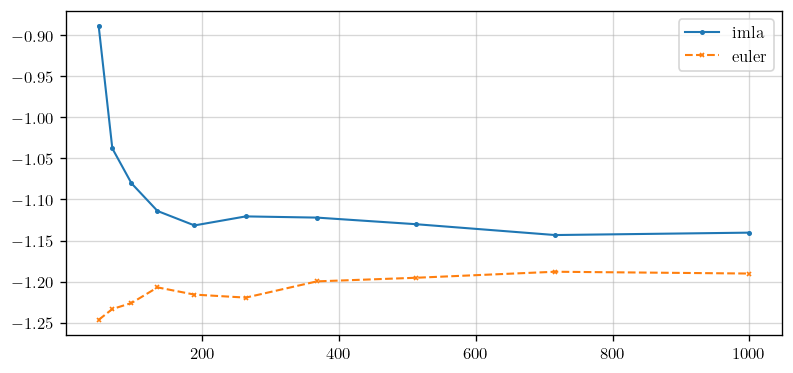

In [ ]:
# Old plot with tol 1e-6 and max_crossings = 0.15
fig, ax = plt.subplots()

ax.plot(N_range, max_exp_imla, marker = 'o', label = "imla")
ax.plot(N_range, max_exp_euler, marker = 'x', linestyle = '--', label = "euler")

ax.legend()
plt.show()

---

Test the results.

---
---
---

How does the Newton tolerance influence?

In [ ]:
crossings = [0.1, 0.2, 0.3, 0.4]
results_both = {}

N_range = np.logspace(np.log10(100), np.log10(750), 10, dtype = int)
M = 100; beta = 2; pot_int = 2; newton_tol = 1e-6;

exp_min = -3.0; exp_max = 0.0; # e.g. dt = 10^0 = 1.
search_tol = 1e-3

for max_crossings in crossings:  
    clear_output(wait = True)

    max_exp_imla = np.zeros(len(N_range), dtype = float)
    max_exp_euler = np.zeros(len(N_range), dtype = float)
    mean_newton_iters = np.zeros(len(N_range), dtype = float)
    mean_cg_iters = np.zeros(len(N_range), dtype = float)
    
    for j, N in enumerate(N_range):
        print(f"Crossing {max_crossings} on N {N}")
        init = random_matrix.init_quartic_eigenvalues(M, N, dt = 0.05)
        exponent, info = find_max_dt_exponent(init, N, "imla", max_crossings, 
                        exp_min, exp_max, search_tol, newton_tol = newton_tol)
        
        max_exp_imla[j] = exponent
        mean_newton_iters[j] = info["newton"].mean()
        mean_cg_iters[j] = info["cg"].mean()

        euler_exponent, _ = find_max_dt_exponent(init, N, "euler", max_crossings, 
                        exp_min, exp_max, search_tol)
        max_exp_euler[j] = euler_exponent
        
    results_both[max_crossings] = {
        "euler_exp": max_exp_euler,
        "imla_exp": max_exp_imla,
        "mean_newton": mean_newton_iters,
        "mean_cg": mean_cg_iters,
    }

In [17]:
results_both[0.1]

{'euler_exp': array([-1.28759766, -1.29345703, -1.2421875 , -1.2421875 , -1.25537109,
        -1.24438477, -1.24438477, -1.2253418 , -1.20410156, -1.22167969]),
 'imla_exp': array([-1.10888672, -1.14038086, -1.14477539, -1.15356445, -1.16674805,
        -1.1652832 , -1.15722656, -1.16015625, -1.1484375 , -1.16308594]),
 'mean_newton': array([4.35, 4.27, 4.29, 4.28, 4.2 , 4.17, 4.17, 4.13, 4.12, 4.12]),
 'mean_cg': array([5.98016667, 5.6045    , 5.538     , 5.40166667, 5.14466667,
        5.10466667, 5.08133333, 4.9685    , 5.0305    , 4.859     ])}

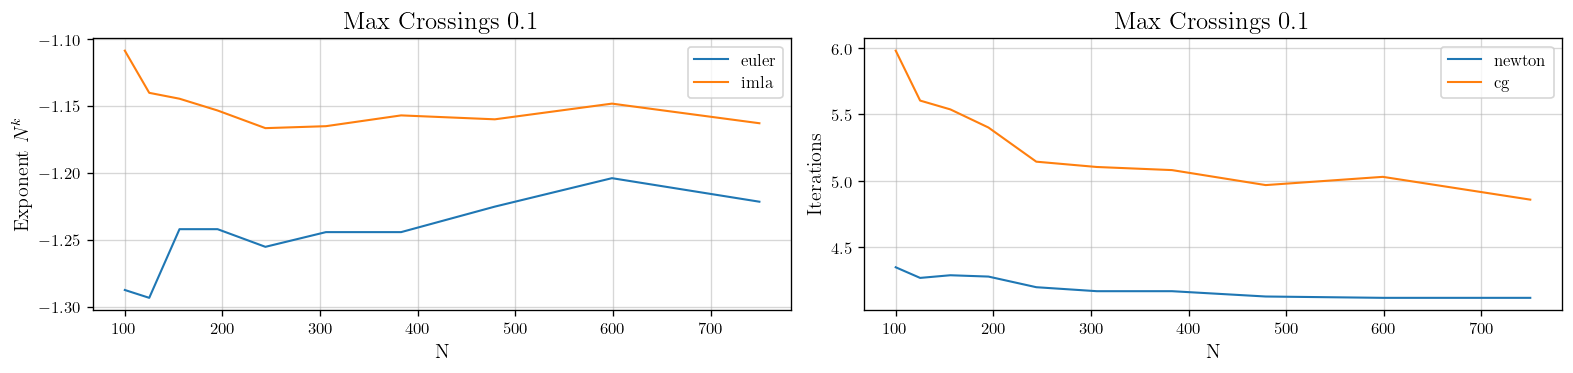

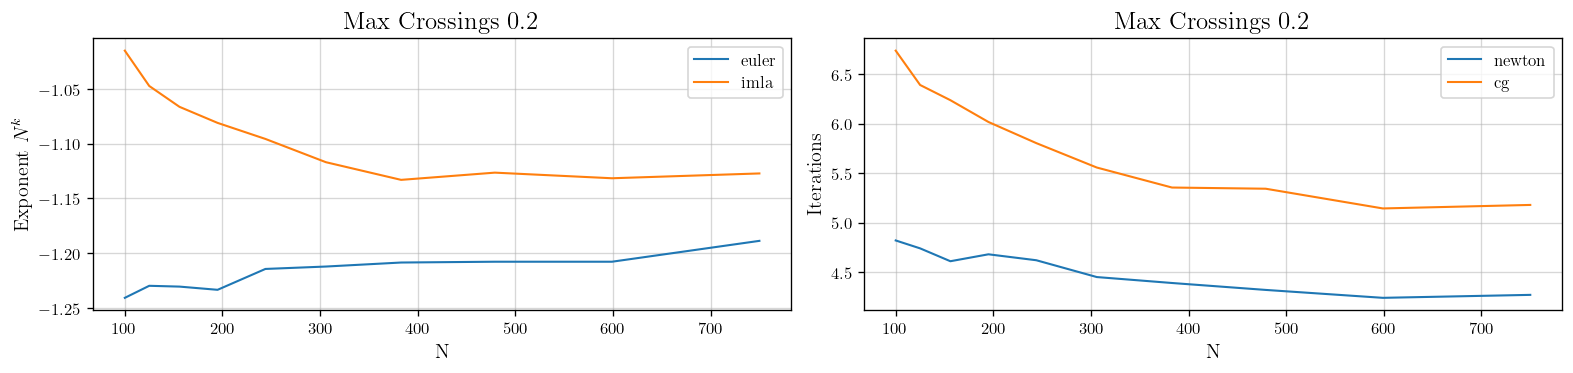

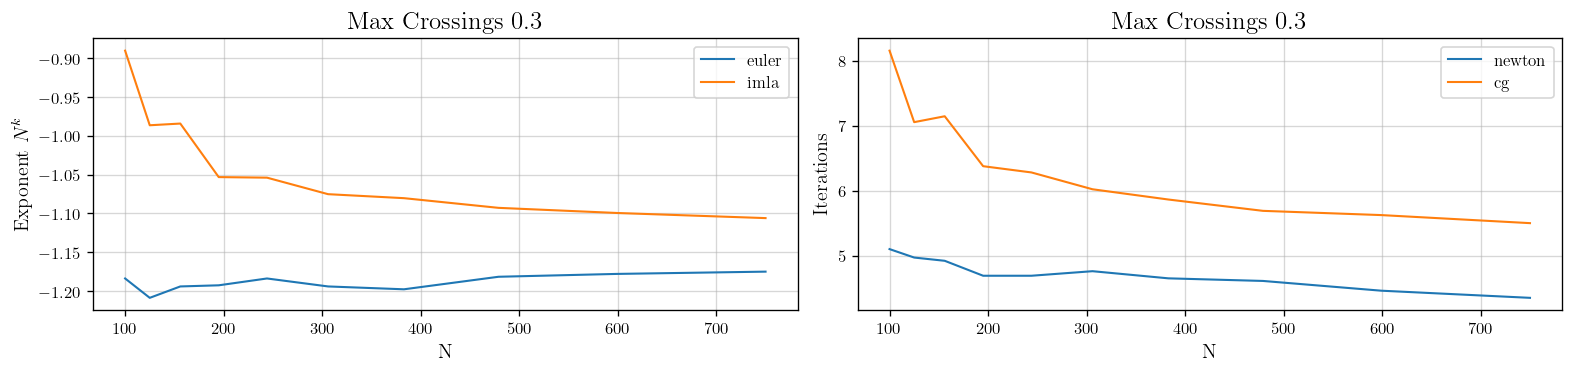

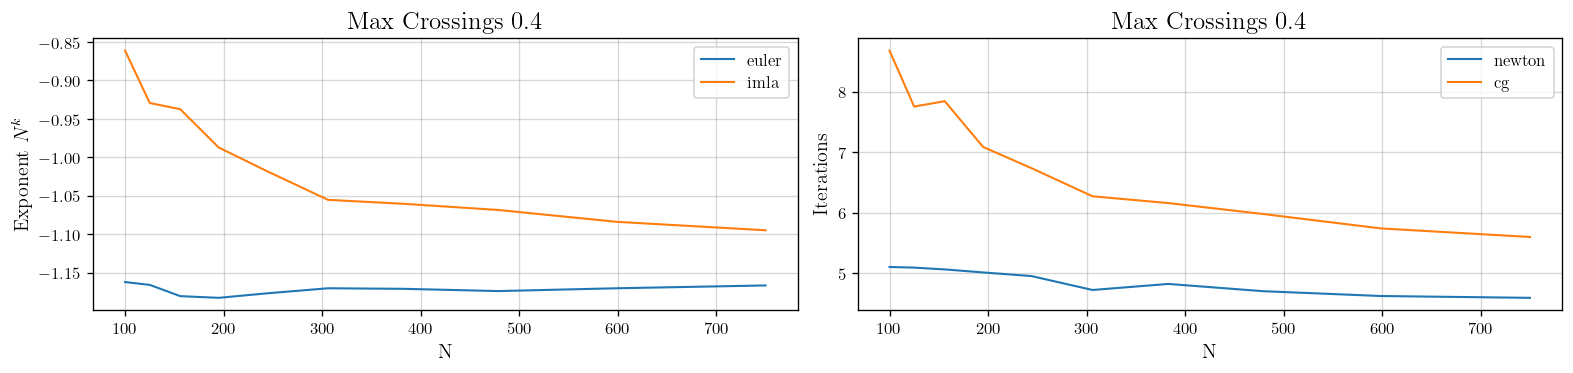

In [20]:
for cross_max in crossings:
    data = results_both[cross_max]
    fig, axes = plt.subplots(1, 2, figsize = (13, 3))
    ax1, ax2 = axes
    Ns = results_both["N_range"]

    ax1.plot(Ns, data["euler_exp"], label = "euler")
    ax1.plot(Ns, data["imla_exp"], label = "imla")
    ax1.set_ylabel(r"Exponent $N^k$")

    ax2.plot(Ns, data["mean_newton"], label = "newton")
    ax2.plot(Ns, data["mean_cg"], label = "cg")
    ax2.set_ylabel("Iterations")

    for ax in axes:
        ax.set_xlabel("N")
        ax.legend()
        ax.set_title(f"Max Crossings {cross_max}", fontsize = 15)

    plt.show()

In [13]:
path = "imla-euler-max-crossings-main.pkl"
with open (path, "wb") as f:
    pickle.dump(results_both, f)

---
---
---

Old plots from the experiments with two tolerances (saved).

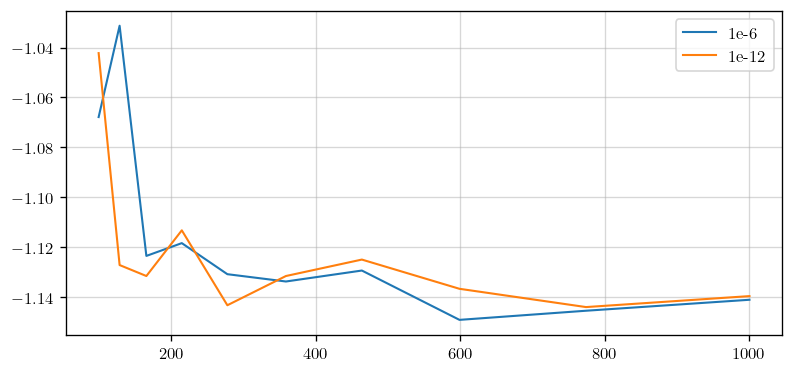

In [10]:
fig, ax = plt.subplots()
ax.plot(N_range, results[1e-6]["max_exp"], label = "1e-6")
ax.plot(N_range, results[1e-12]["max_exp"], label = "1e-12")

ax.legend()

plt.show()

---
---
---

Can crossings occur for explicit Euler of just the repulsion?

In [21]:
@njit
def euler_step(x, beta, dt):
    M, N = x.shape
    coulomb = forces.coulomb_interaction(x) # Returns 1/N*sum
    noise = np.random.normal(0.0, 1.0, x.shape)

    return x + coulomb*dt

# ================
M, N = 100, 30
init = random_matrix.init_gue_eigenvalues(M, N)
beta = 2.0; dt = 1/N; T = 3.0; total_steps = int(T/dt);

trajectory = []
state = np.copy(init)
for j in range(total_steps):
    trajectory.append(state)
    state = euler_step(state, beta, dt)

trajectory = np.array(trajectory)

In [22]:
# Trajectory is shape steps, trials, N.
@njit
def count_crossings(trajectory):
    total_steps, M, N = trajectory.shape
    crossings_per_step = np.zeros(total_steps, dtype = float)

    for step in range(total_steps):
        step_crossings = 0

        for m in range(M):
            x = trajectory[step, m]
            crossing = False 

            for j in range(N - 1):
                if (x[j] >= x[j + 1]):
                    crossing = True
                    break

            if (crossing):
                step_crossings += 1

        crossings_per_step[step] = step_crossings/M

    return crossings_per_step 

count_crossings(trajectory)

array([0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01])